In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer

warnings.filterwarnings('ignore')

In [38]:
df = pd.read_csv("https://raw.githubusercontent.com/kzming2007/UR3_Cobot_ML/refs/heads/main/dataset/ur3_cobotops.csv")

## linear regression(normal)

In [39]:
# 1. 결측치 없는 클린 데이터 로드 및 분리
df_clean = df.dropna().copy()

# 입력 피처(X): 12개 조인트 피처
input_cols = [
    'Current_J0', 'Current_J1', 'Current_J2', 'Current_J3', 'Current_J4', 'Current_J5',
    'Speed_J0', 'Speed_J1', 'Speed_J2', 'Speed_J3', 'Speed_J4', 'Speed_J5'
]
X = df_clean[input_cols]

# 타겟(y): 그리퍼 전류
y = df_clean['Tool_current']

# 2. Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. 비교할 스케일러 정의
scalers = {
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": MinMaxScaler()
}

print("--- [최적 피벗] 그리퍼 전류(Tool_current) 스케일러별 회귀 결과 ---")

# 4. 루프를 돌며 스케일러별 학습 및 평가
for name, scaler in scalers.items():
    # 데이터 스케일링
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # 모델 학습 및 예측
    model = LinearRegression()
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    # 결과 출력
    print(f"\n[{name} 결과]")
    print(f"R² (결정계수): {r2_score(y_test, y_pred):.4f}")
    print(f"MSE (평균제곱오차): {mean_squared_error(y_test, y_pred):.6f}")

--- [최적 피벗] 그리퍼 전류(Tool_current) 스케일러별 회귀 결과 ---

[StandardScaler 결과]
R² (결정계수): 0.1047
MSE (평균제곱오차): 0.004917

[MinMaxScaler 결과]
R² (결정계수): 0.1047
MSE (평균제곱오차): 0.004917


### PolynomialFeatures 적용

In [40]:
print("--- [Poly 적용 후] 그리퍼 전류(Tool_current) 스케일러별 회귀 결과 ---")

# 4. 루프를 돌며 스케일러별 학습 및 평가
for name, scaler in scalers.items():
    # [수정] 훈련 데이터로 스케일러 학습(fit) 후 변환(transform)
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # 다항 피처 변환 (Degree=2)
    poly = PolynomialFeatures(degree=2, include_bias=False)
    X_train_poly = poly.fit_transform(X_train_scaled)
    X_test_poly = poly.transform(X_test_scaled)

    # 모델 학습
    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    # 예측
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)

    # 결과 출력
    print(f"\n[{name} 결과]")
    # [수정] 과적합(Overfitting) 여부를 판단하기 위해 Train과 Test 점수를 함께 비교합니다.
    print(f"Train R² (결정계수): {r2_score(y_train, y_train_pred):.4f} | Train MSE: {mean_squared_error(y_train, y_train_pred):.6f}")
    print(f"Test  R² (결정계수): {r2_score(y_test, y_test_pred):.4f} | Test  MSE: {mean_squared_error(y_test, y_test_pred):.6f}")

--- [Poly 적용 후] 그리퍼 전류(Tool_current) 스케일러별 회귀 결과 ---

[StandardScaler 결과]
Train R² (결정계수): 0.2786 | Train MSE: 0.004611
Test  R² (결정계수): 0.2340 | Test  MSE: 0.004207

[MinMaxScaler 결과]
Train R² (결정계수): 0.2786 | Train MSE: 0.004611
Test  R² (결정계수): 0.2340 | Test  MSE: 0.004207


### poly & 규제 적용

In [42]:
# 1. 탐색할 하이퍼파라미터 리스트 정의
alphas_ridge = [0.01, 0.1, 1.0, 10.0, 100.0]
alphas_lasso = [0.0001, 0.001, 0.01, 0.1, 1.0]  # Lasso는 더 작은 값을 촘촘히 탐색
alphas_elastic = [0.0001, 0.001, 0.01, 0.1]
l1_ratios = [0.2, 0.5, 0.8]  # ElasticNet 전용 (L1 규제의 비율)

scalers = {
    "Standard": StandardScaler(),
    "MinMax": MinMaxScaler()
}

results = []

print("--- 하이퍼파라미터 탐색 중 (잠시만 기다려주세요) ---")

# 2. Pipeline을 사용하여 전처리 캡슐화 (데이터 누수 방지)
for s_name, base_scaler in scalers.items():

    # --- Ridge 탐색 ---
    for a in alphas_ridge:
        pipeline = Pipeline([
            ('scaler', clone(base_scaler)),
            ('poly', PolynomialFeatures(degree=2, include_bias=False)),
            ('model', Ridge(alpha=a))
        ])
        pipeline.fit(X_train, y_train)
        pred = pipeline.predict(X_test)
        results.append({"Scaler": s_name, "Model": "Ridge", "Alpha": a, "L1_Ratio": "-",
                        "R2": r2_score(y_test, pred), "MSE": mean_squared_error(y_test, pred)})

    # --- Lasso 탐색 ---
    for a in alphas_lasso:
        pipeline = Pipeline([
            ('scaler', clone(base_scaler)),
            ('poly', PolynomialFeatures(degree=2, include_bias=False)),
            ('model', Lasso(alpha=a, max_iter=5000, random_state=42))
        ])
        pipeline.fit(X_train, y_train)
        pred = pipeline.predict(X_test)
        results.append({"Scaler": s_name, "Model": "Lasso", "Alpha": a, "L1_Ratio": "-",
                        "R2": r2_score(y_test, pred), "MSE": mean_squared_error(y_test, pred)})

    # --- ElasticNet 탐색 ---
    for a in alphas_elastic:
        for l1 in l1_ratios:
            pipeline = Pipeline([
                ('scaler', clone(base_scaler)),
                ('poly', PolynomialFeatures(degree=2, include_bias=False)),
                ('model', ElasticNet(alpha=a, l1_ratio=l1, max_iter=5000, random_state=42))
            ])
            pipeline.fit(X_train, y_train)
            pred = pipeline.predict(X_test)
            results.append({"Scaler": s_name, "Model": "ElasticNet", "Alpha": a, "L1_Ratio": l1,
                            "R2": r2_score(y_test, pred), "MSE": mean_squared_error(y_test, pred)})

# 4. 결과 정리 및 상위 10개 출력
df_res = pd.DataFrame(results)

# R2 기준 내림차순 정렬
df_res_sorted = df_res.sort_values(by="R2", ascending=False).reset_index(drop=True)

# 순위 부여
df_res_sorted.index = df_res_sorted.index + 1
df_res_sorted.index.name = "Rank"

print("\n--- [최적화 결과] 선형 규제 모델 상위 10개 성능 ---")
# 가독성을 위해 포맷팅 적용하여 10개 출력
display(df_res_sorted.head(10).style.format({
    "Alpha": "{:.4f}",
    "R2": "{:.4f}",
    "MSE": "{:.6f}"
}))

--- 하이퍼파라미터 탐색 중 (잠시만 기다려주세요) ---

--- [최적화 결과] 선형 규제 모델 상위 10개 성능 ---


,Scaler,Model,Alpha,L1_Ratio,R2,MSE
Rank,,,,,,
1,Standard,Ridge,0.0100,-,0.2340,0.004207
2,Standard,Ridge,0.1000,-,0.2340,0.004207
3,Standard,Ridge,1.0000,-,0.2340,0.004207
4,Standard,Ridge,10.0000,-,0.2340,0.004207
5,Standard,ElasticNet,0.0001,0.500000,0.2334,0.004210
6,Standard,ElasticNet,0.0001,0.200000,0.2334,0.004210
7,Standard,ElasticNet,0.0001,0.800000,0.2325,0.004215
8,Standard,Lasso,0.0001,-,0.2322,0.004217
9,Standard,Ridge,100.0000,-,0.2309,0.004224


### k fold & poly & 규제 적용

In [43]:
warnings.filterwarnings('ignore')

# 1. 탐색할 하이퍼파라미터 리스트 정의
alphas_ridge = [0.01, 0.1, 1.0, 10.0, 100.0]
alphas_lasso = [0.0001, 0.001, 0.01, 0.1, 1.0]
alphas_elastic = [0.0001, 0.001, 0.01, 0.1]
l1_ratios = [0.2, 0.5, 0.8]

# 딕셔너리에는 '원본' 스케일러 객체 하나만 담아둡니다.
scalers = {
    "Standard": StandardScaler(),
    "MinMax": MinMaxScaler()
}

results = []

# 시계열 순서를 섞기 위해 shuffle=True, 재현성을 위해 random_state 고정
kf = KFold(n_splits=5, shuffle=True, random_state=42)

print("--- 하이퍼파라미터 탐색 중 (데이터 셔플링 교차 검증 진행) ---")

# 2. 모델별 하이퍼파라미터 루프 진행
for s_name, base_scaler in scalers.items():

    # --- 1) Ridge 탐색 ---
    for a in alphas_ridge:
        pipeline_ridge = Pipeline([
            ('scaler', clone(base_scaler)),
            ('poly', PolynomialFeatures(degree=2, include_bias=False)),
            ('model', Ridge(alpha=a))
        ])

        cv_scores = cross_val_score(pipeline_ridge, X_train, y_train, cv=kf, scoring='r2', n_jobs=-1)

        results.append({
            "Scaler": s_name, "Model": "Ridge", "Alpha": a, "L1_Ratio": "-",
            "CV_Mean_R2": np.mean(cv_scores), "pipeline_obj": pipeline_ridge
        })

    # --- 2) Lasso 탐색 ---
    for a in alphas_lasso:
        pipeline_lasso = Pipeline([
            ('scaler', clone(base_scaler)),
            ('poly', PolynomialFeatures(degree=2, include_bias=False)),
            ('model', Lasso(alpha=a, max_iter=10000, random_state=42))
        ])

        cv_scores = cross_val_score(pipeline_lasso, X_train, y_train, cv=kf, scoring='r2', n_jobs=-1)

        results.append({
            "Scaler": s_name, "Model": "Lasso", "Alpha": a, "L1_Ratio": "-",
            "CV_Mean_R2": np.mean(cv_scores), "pipeline_obj": pipeline_lasso
        })

    # --- 3) ElasticNet 탐색 ---
    for a in alphas_elastic:
        for l1 in l1_ratios:
            pipeline_elastic = Pipeline([
                ('scaler', clone(base_scaler)),
                ('poly', PolynomialFeatures(degree=2, include_bias=False)),
                ('model', ElasticNet(alpha=a, l1_ratio=l1, max_iter=10000, random_state=42))
            ])

            cv_scores = cross_val_score(pipeline_elastic, X_train, y_train, cv=kf, scoring='r2', n_jobs=-1)

            results.append({
                "Scaler": s_name, "Model": "ElasticNet", "Alpha": a, "L1_Ratio": l1,
                "CV_Mean_R2": np.mean(cv_scores), "pipeline_obj": pipeline_elastic
            })

# 3. 결과 정리 및 정렬 (교차 검증 평균 R2 점수 기준 내림차순)
df_res = pd.DataFrame(results)
df_res_sorted = df_res.sort_values(by="CV_Mean_R2", ascending=False).reset_index(drop=True)

# 4. 교차 검증 기준 상위 10개 모델에 대해서만 Test 세트 최종 평가 진행
final_results = []
for i in range(min(10, len(df_res_sorted))):
    row = df_res_sorted.iloc[i]
    best_pipeline = row['pipeline_obj']

    # 파이프라인 전체를 학습 (스케일러 핏 -> 다항식 변환 -> 모델 학습이 한 번에 진행됨)
    best_pipeline.fit(X_train, y_train)

    # Test 데이터에 대해 예측 진행
    pred = best_pipeline.predict(X_test)

    final_results.append({
        "Rank": i + 1,
        "Scaler": row['Scaler'],
        "Model": row['Model'],
        "Alpha": row['Alpha'],
        "L1_Ratio": row['L1_Ratio'],
        "CV Train R²": row['CV_Mean_R2'],
        "Test R²": r2_score(y_test, pred),
        "Test MSE": mean_squared_error(y_test, pred)
    })

# 5. 최종 결과 DataFrame 생성 및 출력
df_final = pd.DataFrame(final_results).set_index("Rank")

print("\n--- [최적화 완료] 교차 검증 기반 상위 10개 모델의 최종 Test 세트 성능 ---")
display(df_final.style.format({
    "Alpha": "{:.4f}",
    "CV Train R²": "{:.4f}",
    "Test R²": "{:.4f}",
    "Test MSE": "{:.6f}"
}))

--- 하이퍼파라미터 탐색 중 (데이터 셔플링 교차 검증 진행) ---

--- [최적화 완료] 교차 검증 기반 상위 10개 모델의 최종 Test 세트 성능 ---


,Scaler,Model,Alpha,L1_Ratio,CV Train R²,Test R²,Test MSE
Rank,,,,,,,
1,MinMax,Ridge,0.0100,-,0.2499,0.2298,0.004230
2,Standard,ElasticNet,0.0001,0.500000,0.2495,0.2334,0.004210
3,Standard,Ridge,10.0000,-,0.2495,0.2340,0.004207
4,Standard,ElasticNet,0.0001,0.800000,0.2495,0.2325,0.004215
5,Standard,ElasticNet,0.0001,0.200000,0.2494,0.2334,0.004210
6,Standard,Lasso,0.0001,-,0.2492,0.2322,0.004217
7,Standard,Ridge,1.0000,-,0.2487,0.2340,0.004207
8,Standard,Ridge,0.1000,-,0.2483,0.2340,0.004207
9,Standard,Ridge,0.0100,-,0.2482,0.2340,0.004207


#

#Current & Speed 12개 PCA

=== 1. PCA를 위한 데이터 표준화(StandardScaler)를 진행합니다 ===

[각 주성분(PC)의 분산 설명력 및 누적 설명력]
Principal Component  Explained Variance (%)  Cumulative Variance (%)
                PC1                   26.35                    26.35
                PC2                   20.57                    46.92
                PC3                   15.92                    62.84
                PC4                   12.57                    75.41
                PC5                    8.92                    84.33
                PC6                    5.56                    89.89
                PC7                    3.13                    93.03
                PC8                    2.51                    95.54
                PC9                    2.08                    97.63
               PC10                    1.38                    99.00
               PC11                    0.97                    99.97
               PC12                    0.03                   100.00


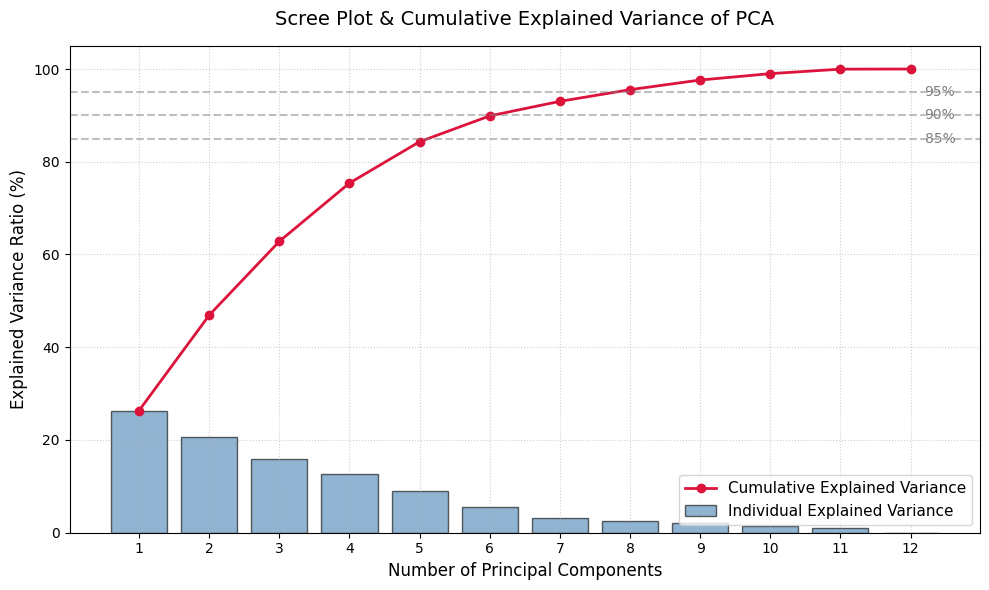

In [21]:
# ==========================================
# 0. 변수명 정의 및 결측치 전처리 (누락 방지)
# ==========================================
# 관절 전류 컬럼 6개 정의 ('Current_J0' ~ 'Current_J5')
current_cols = [f'Current_J{i}' for i in range(6)]

# 관절 속도 컬럼 6개 정의 ('Speed_J0' ~ 'Speed_J5')
speed_cols = [f'Speed_J{i}' for i in range(6)]

# 혹시 모를 결측치 제거 처리 (7,409행 -> 7,355행으로 정제)
df_clean = df.dropna()


# ==========================================
# 1. 데이터 준비 및 표준화 (PCA 전 필수 단계)
# ==========================================
print("=== 1. PCA를 위한 데이터 표준화(StandardScaler)를 진행합니다 ===")
# 독립변수(X) 12개 추출
X_features = df_clean[current_cols + speed_cols]

# PCA는 단위에 매우 민감하므로 반드시 표준화해야 합니다.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)


# ==========================================
# 2. PCA 모델 학습 (전체 12차원 생성)
# ==========================================
# 변수 개수(12개)만큼의 주성분(PC)을 모두 만듭니다.
pca_full = PCA(n_components=12)
X_pca = pca_full.fit_transform(X_scaled)


# ==========================================
# 3. 설명 분산 비율 계산 및 누적 분산(Cumulative Variance) 계산
# ==========================================
# 각 주성분이 원본 데이터의 정보를 얼마나 설명하는지(%)
exp_var_ratio = pca_full.explained_variance_ratio_ * 100

# 누적 설명 분산 비율(%) 계산
cum_exp_var_ratio = np.cumsum(exp_var_ratio)

# 결과를 깔끔한 테이블로 출력
print("\n[각 주성분(PC)의 분산 설명력 및 누적 설명력]")
pca_summary = pd.DataFrame({
    'Principal Component': [f'PC{i+1}' for i in range(12)],
    'Explained Variance (%)': exp_var_ratio,
    'Cumulative Variance (%)': cum_exp_var_ratio
})
print(pca_summary.round(2).to_string(index=False))


# ==========================================
# 4. 시각화: Scree Plot 및 누적 설명 분산 그래프
# ==========================================
plt.figure(figsize=(10, 6))

# 1) 막대 그래프 (개별 PC가 가지는 설명력)
plt.bar(
    range(1, 13),
    exp_var_ratio,
    alpha=0.6,
    color='steelblue',
    edgecolor='black',
    label='Individual Explained Variance'
)

# 2) 선 그래프 (주성분이 누적되면서 더해지는 설명력)
plt.plot(
    range(1, 13),
    cum_exp_var_ratio,
    marker='o',
    color='crimson',
    linewidth=2,
    label='Cumulative Explained Variance'
)

# 3) 학계/실무에서 주로 사용하는 기준 점선 표시 (85%, 90%, 95%)
plt.axhline(y=85, color='gray', linestyle='--', alpha=0.5)
plt.text(12.2, 85, '85%', color='gray', va='center')
plt.axhline(y=90, color='gray', linestyle='--', alpha=0.5)
plt.text(12.2, 90, '90%', color='gray', va='center')
plt.axhline(y=95, color='gray', linestyle='--', alpha=0.5)
plt.text(12.2, 95, '95%', color='gray', va='center')

# 그래프 스타일링
plt.title('Scree Plot & Cumulative Explained Variance of PCA', fontsize=14, pad=15)
plt.xlabel('Number of Principal Components', fontsize=12)
plt.ylabel('Explained Variance Ratio (%)', fontsize=12)
plt.xticks(range(1, 13))
plt.ylim(0, 105)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [44]:
# GridSearchCV를 위한 하이퍼파라미터 그리드 정의
param_grid_ridge = {'model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}
param_grid_lasso = {'model__alpha': [0.0001, 0.001, 0.01, 0.1, 1.0]}
param_grid_elastic = {
    'model__alpha': [0.0001, 0.001, 0.01, 0.1],
    'model__l1_ratio': [0.2, 0.5, 0.8]
}

cv_splits = 5
pca_tuning_results = []

# PC7과 PC8 두 가지 케이스에 대해 순차적으로 루프를 돌며 최적화 진행
for n_pcs in [7, 8]:
    print(f"\n--- [PC {n_pcs} 차원 축소 버전] Grid Search를 진행 중입니다 ---")

    # ==========================================
    # A. Ridge (PCA 기반) — Pipeline으로 전처리 캡슐화
    # ==========================================
    pipeline_ridge = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=n_pcs, random_state=42)),
        ('model', Ridge(random_state=42))
    ])
    grid_ridge = GridSearchCV(
        pipeline_ridge,
        param_grid_ridge,
        cv=cv_splits,
        scoring='neg_mean_squared_error',
        n_jobs=-1
    )
    grid_ridge.fit(X_train, y_train)

    best_ridge = grid_ridge.best_estimator_
    y_pred_r = best_ridge.predict(X_test)
    r2_r = r2_score(y_test, y_pred_r)
    mse_r = mean_squared_error(y_test, y_pred_r)
    rmse_r = np.sqrt(mse_r)

    pca_tuning_results.append([f'PCA (PC {n_pcs})', 'Ridge', str(grid_ridge.best_params_), r2_r, mse_r, rmse_r])

    # ==========================================
    # B. Lasso (PCA 기반) — Pipeline으로 전처리 캡슐화
    # ==========================================
    pipeline_lasso = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=n_pcs, random_state=42)),
        ('model', Lasso(max_iter=10000, random_state=42))
    ])
    grid_lasso = GridSearchCV(
        pipeline_lasso,
        param_grid_lasso,
        cv=cv_splits,
        scoring='neg_mean_squared_error',
        n_jobs=-1
    )
    grid_lasso.fit(X_train, y_train)

    best_lasso = grid_lasso.best_estimator_
    y_pred_l = best_lasso.predict(X_test)
    r2_l = r2_score(y_test, y_pred_l)
    mse_l = mean_squared_error(y_test, y_pred_l)
    rmse_l = np.sqrt(mse_l)

    pca_tuning_results.append([f'PCA (PC {n_pcs})', 'Lasso', str(grid_lasso.best_params_), r2_l, mse_l, rmse_l])

    # ==========================================
    # C. ElasticNet (PCA 기반) — Pipeline으로 전처리 캡슐화
    # ==========================================
    pipeline_elastic = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=n_pcs, random_state=42)),
        ('model', ElasticNet(max_iter=10000, random_state=42))
    ])
    grid_elastic = GridSearchCV(
        pipeline_elastic,
        param_grid_elastic,
        cv=cv_splits,
        scoring='neg_mean_squared_error',
        n_jobs=-1
    )
    grid_elastic.fit(X_train, y_train)

    best_elastic = grid_elastic.best_estimator_
    y_pred_e = best_elastic.predict(X_test)
    r2_e = r2_score(y_test, y_pred_e)
    mse_e = mean_squared_error(y_test, y_pred_e)
    rmse_e = np.sqrt(mse_e)

    pca_tuning_results.append([f'PCA (PC {n_pcs})', 'ElasticNet', str(grid_elastic.best_params_), r2_e, mse_e, rmse_e])

# ==========================================
# 결과 출력 및 데이터프레임 생성
# ==========================================
df_pca_best = pd.DataFrame(
    pca_tuning_results,
    columns=['Dimension', 'Model', 'Best Hyperparameters', 'R2 (Test)', 'MSE', 'RMSE']
)

print("\n" + "="*85 + "\n")
print("=== [5단계] PCA (PC 7 vs PC 8) 하이퍼파라미터 최적화 모델 최종 비교 ===")
print(df_pca_best.round(6).to_string(index=False))


--- [PC 7 차원 축소 버전] Grid Search를 진행 중입니다 ---

--- [PC 8 차원 축소 버전] Grid Search를 진행 중입니다 ---


=== [5단계] PCA (PC 7 vs PC 8) 하이퍼파라미터 최적화 모델 최종 비교 ===
 Dimension      Model                            Best Hyperparameters  R2 (Test)      MSE     RMSE
PCA (PC 7)      Ridge                         {'model__alpha': 100.0}   0.022211 0.005370 0.073279
PCA (PC 7)      Lasso                        {'model__alpha': 0.0001}   0.022120 0.005370 0.073283
PCA (PC 7) ElasticNet {'model__alpha': 0.001, 'model__l1_ratio': 0.5}   0.021197 0.005375 0.073317
PCA (PC 8)      Ridge                         {'model__alpha': 100.0}   0.029237 0.005331 0.073016
PCA (PC 8)      Lasso                        {'model__alpha': 0.0001}   0.029115 0.005332 0.073020
PCA (PC 8) ElasticNet {'model__alpha': 0.001, 'model__l1_ratio': 0.2}   0.028888 0.005333 0.073029


In [23]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score

# ==========================================
# 1. 데이터 분할 (재확인)
# ==========================================
# 앞서 정의한 current_cols, speed_cols 사용
X = df_clean[current_cols + speed_cols]
y = df_clean['Tool_current']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# 2. 파이프라인(Pipeline) 및 하이퍼파라미터 그리드 설계
# ==========================================
# Pipeline은 '스케일링 -> PCA -> 회귀모델'을 한 번에 묶어서 데이터 누수를 방지합니다.
pipelines = {
    'PCA_Ridge': Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(random_state=42)),
        ('model', Ridge(random_state=42))
    ]),
    'PCA_Lasso': Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(random_state=42)),
        ('model', Lasso(max_iter=10000, random_state=42))
    ]),
    'PCA_ElasticNet': Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(random_state=42)),
        ('model', ElasticNet(max_iter=10000, random_state=42))
    ])
}

# pca__n_components 에 [7, 8]을 넣어 어떤 개수가 최적인지 AI가 직접 찾게 합니다.
param_grids = {
    'PCA_Ridge': {
        'pca__n_components': [7, 8],
        'model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]
    },
    'PCA_Lasso': {
        'pca__n_components': [7, 8],
        'model__alpha': [0.0001, 0.001, 0.01, 0.1, 1.0]
    },
    'PCA_ElasticNet': {
        'pca__n_components': [7, 8],
        'model__alpha': [0.0001, 0.001, 0.01, 0.1],
        'model__l1_ratio': [0.2, 0.5, 0.8]
    }
}

# ==========================================
# 3. GridSearchCV 5-Fold 학습 및 최적 모델 추출
# ==========================================
pca_best_results = []

print("=== 5단계: PCA(7,8) 기반 K-Fold GridSearchCV 탐색을 시작합니다 ===")

for model_name in pipelines.keys():
    print(f"{model_name} 탐색 중...")

    # GridSearchCV 세팅
    grid_search = GridSearchCV(
        estimator=pipelines[model_name],
        param_grid=param_grids[model_name],
        cv=5,
        scoring='neg_mean_squared_error',
        n_jobs=-1
    )

    # 학습 수행
    grid_search.fit(X_train, y_train)

    # 최적 모델로 Test 데이터 평가
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    # 최적 파라미터 추출 (PC 개수와 규제값)
    best_params = grid_search.best_params_

    pca_best_results.append([
        model_name,
        best_params['pca__n_components'],
        best_params.get('model__alpha', 'N/A'),
        best_params.get('model__l1_ratio', 'N/A'),
        r2, mse, rmse
    ])

# ==========================================
# 4. 결과 출력
# ==========================================
df_pca_results = pd.DataFrame(
    pca_best_results,
    columns=['Model', 'Best PC Count', 'Best Alpha', 'Best L1_Ratio', 'R2 (Test)', 'MSE', 'RMSE']
)

print("\n" + "="*80)
print("=== [5단계] PCA(7,8) & 규제 회귀 GridSearchCV 최종 결과 ===")
print(df_pca_results.round(6).to_string(index=False))

=== 5단계: PCA(7,8) 기반 K-Fold GridSearchCV 탐색을 시작합니다 ===
PCA_Ridge 탐색 중...
PCA_Lasso 탐색 중...
PCA_ElasticNet 탐색 중...

=== [5단계] PCA(7,8) & 규제 회귀 GridSearchCV 최종 결과 ===
         Model  Best PC Count  Best Alpha Best L1_Ratio  R2 (Test)      MSE     RMSE
     PCA_Ridge              8    100.0000           N/A   0.029237 0.005331 0.073016
     PCA_Lasso              8      0.0001           N/A   0.029115 0.005332 0.073020
PCA_ElasticNet              8      0.0010           0.2   0.028888 0.005333 0.073029


In [24]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error, r2_score

# 1. 데이터 준비 (앞선 단계와 동일)
X = df_clean[current_cols + speed_cols]
y = df_clean['Tool_current']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. 독립 분할 PCA를 위한 ColumnTransformer 설계
# Current 그룹과 Speed 그룹을 각각 스케일링 후 PCA 적용 (각각 3개의 PC 추출로 임의 설정, GridSearch에서 조정 가능)
pca_current = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(random_state=42))
])

pca_speed = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(random_state=42))
])

# ColumnTransformer를 이용해 두 파이프라인을 병렬로 병합
preprocessor = ColumnTransformer(
    transformers=[
        ('curr_pca', pca_current, current_cols),
        ('spd_pca', pca_speed, speed_cols)
    ]
)

# 3. 최종 파이프라인 구축 (전처리 병합 -> 규제 모델 학습)
# 첨부된 이미지에서 가장 성능이 좋았던 ElasticNet을 기본으로 설정
pipeline_split_pca = Pipeline([
    ('preprocessor', preprocessor),
    ('model', ElasticNet(max_iter=10000, random_state=42))
])

# 4. 하이퍼파라미터 그리드 설정
# Current PC 개수, Speed PC 개수, ElasticNet 규제값을 동시에 탐색
param_grid = {
    'preprocessor__curr_pca__pca__n_components': [3, 4, 5], # Current 차원 축소 개수
    'preprocessor__spd_pca__pca__n_components': [3, 4, 5],  # Speed 차원 축소 개수
    'model__alpha': [0.0001, 0.001, 0.01],
    'model__l1_ratio': [0.2, 0.5, 0.8]
}

# 5. GridSearchCV 실행
print("--- [6단계] Current / Speed 독립 분할 PCA 기반 K-Fold 최적화 시작 ---")
grid_split_pca = GridSearchCV(
    pipeline_split_pca,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid_split_pca.fit(X_train, y_train)

# 6. 결과 평가 및 출력
best_model = grid_split_pca.best_estimator_
y_pred = best_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"\n[최적 하이퍼파라미터]\n{grid_split_pca.best_params_}")
print("-" * 50)
print(f"R2 (Test) : {r2:.6f}")
print(f"MSE       : {mse:.6f}")
print(f"RMSE      : {rmse:.6f}")

--- [6단계] Current / Speed 독립 분할 PCA 기반 K-Fold 최적화 시작 ---

[최적 하이퍼파라미터]
{'model__alpha': 0.0001, 'model__l1_ratio': 0.2, 'preprocessor__curr_pca__pca__n_components': 5, 'preprocessor__spd_pca__pca__n_components': 5}
--------------------------------------------------
R2 (Test) : 0.083068
MSE       : 0.005036
RMSE      : 0.070962
